Logs
- [2026/Mar/02]   
  Using `matshow` to plot the percolation causes several problem
  when we want to overlay with other `matshow`.

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib import colors

In [36]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

In [37]:
rng = np.random.default_rng()

## Case Study: Percolation


We will use Monte Carlo simulation to study a natural model known as _percolation_

The term _Monte Carlo simulation_ is broadly used to encompass any computational   
technique that employs randomness to estimate an unknown quantity by performing   
multiple trials (known as _simulations_)

An application of percolation to management science:   
(Khvatova et al., 2016) - How to measure trust - the percolation model applied to intra-organisational knowledge sharing networks

### Percolation

Percolation is an abstract process to model a situation where local interactions in a system implies global properties.   
- An electrical eingeer might be interest in composite systems consisting of    
  randomly distributed insulating and metallic materials: which fraction of  
  the materials needs to be metallic so that the composite system is an electrical conductor?
- A geologist might be interested in a porous landscape with water on the surface   
  (or oil below); under which conditions will the water be able to drain   
  through the bottom (or the oul to gush through to the surface)?
- Spreading of forest fires
- Disease epidemics
- Evolution
- The study of the Internet

A modeled system of $n$-by-$n$ grid of _sites_
- Each site is either _blocked_ or _open_
- Open sites are initially _empty_
- A _full_ site is an open site that can be connected to an open site in    
  the top row via a chain of a neighboring (left, right, up, down) open sites.
- If tehre is a full sites in the bottom row, then we say the system _percolates_   

In other words, a system percolates if we fill all open sites conected to    
the top row and that process fill some open site on the bottom row.

In a famous scientific problem, researchers are interesed in the following questions:   
if sites are independently set to be open with _vacancy probability_ $p$    
(and therfore blocked with probability $1-p$), what is the probability that    
the system percolates?

### Basic scaffolding

A scaffolding is a technique on developing a computer program that contains    
several files by isolating the side features, like reading and writing files that    
has no relation to the main problem, to different folders and after the program   
side features are solid at the outset, we move to solve the main problem.

We will use _boolean matrices_ to represent if a system will percolate or not.

Let us define it as a function `flow()` with 
- the input argument a boolean matrix `is_open` that specifies which sites
  are open,
- and return another boolean matrix `is_full` that specifies which sites are full.

We also define a function `percolates()` to check whether the boolean matrixc
returned by `flow()` has any full sites on the bottom

A function that performs no computation, such as `flow()`, is sometimes called a _stub_.

In [23]:
def flow(is_open):
  n = len(is_open)
  is_full = [[False for j in range(n)] for i in range(n)]

  # -- We will update the flow computation in here

  return is_full

In [ ]:
def percolates(is_open):
  is_full = flow(is_open)
  n = len(is_full)
  for j in range(n):
    # in is_full matrix, if the last row contains a full site, it means
    # we have a percolation from the top to the bottom
    if is_full[n-1][j]:   # check the last row
      return True

  return False

In [24]:
def read_is_open_mat(filename):
  with open(inp_file, 'r') as fp:
    data = fp.readlines()
    display(data)
    m, n = [int(v) for v in data[0].strip().split(' ')]

    is_open = [[False for j in range(n)] for i in range(m)]
    for i, row in enumerate(data[1:]):
      row = row.strip().split(' ')
      for j in range(n):
        if row[j] == '1':
          is_open[i][j] = True

  return is_open

is_open = read_is_open_mat("test5.txt")

['5 5\n',
 '0 1 1 0 1\n',
 '0 0 1 1 1\n',
 '1 1 0 1 1\n',
 '1 0 0 0 1\n',
 '0 1 1 1 1']

In [21]:
display(flow(is_open))
percolates(is_open)

[[False, False, False, False, False],
 [False, False, False, False, False],
 [False, False, False, False, False],
 [False, False, False, False, False],
 [False, False, False, False, False]]

False

### Vertical percolation

Given a boolean matrix that represents the open sites how do we figure out 
whether it represents a system that percolates

We restrict to the simple case to vertical percolation.   
In this case, we consider only to the vertical connection paths.    
If such a path connects top to bottom in a system, we say that the system 
_vertically percolates_ along the path (and that the system itself vertically 
percolates).   

This restriction is perhaps intuitive if we are talking about sand traveling 
through cement, but not if we are talking about water traveling through cement or
about electrical conductivity

In [29]:
def flow(is_open):
  n = len(is_open)
  is_full = [[False for j in range(n)] for i in range(n)]

  # If we have an open site in the first row, we copy this open site
  # as a full site (it means we can fill the open site)
  for j in range(n):
    is_full[0][j] = is_open[0][j]
  
  for i in range(1, n):
    for j in range(n):
      # for given (i,j)-site, find the next (i+1,j)-site anc check if
      # the site in (i+1,j) is an open site and the site in (i,j) is a full site.
      # If this is true, we can fill (i+1,j) site.
      if is_open[i][j] and is_full[i-1][j]:
        is_full[i][j] = True
  
  return is_full

In [28]:
display(flow(is_open))

percolates(is_open)

[[False, True, True, False, True],
 [False, False, True, False, True],
 [False, False, False, False, True],
 [False, False, False, False, True],
 [False, False, False, False, True]]

True

### Testing

To gain confidence in our code and to develop a better understanding of percolation,
our next goals are to:
- test our code for large random boolean matrices
  - we compose a function `random()` that takes two arguments `n` and `p`
    and generates a random `n`-by-`n` boolean array in which the probability
    that each element is `True` is `p`.
  - we develop a function `draw()` to visualize the contents of a boolean matrix
    as a subdivision of the standard drawing window into squares, one for 
    each site.

- given a vacancy probabilities $p$, estimate the system percolation probability

In [60]:
def bernoulli_trial(p, rng):
  out = 0
  if rng.random() < p:
    out = 1    # Success

  return out

In [61]:
def random_sites(n, p, rng=None):
  a = [[False for j in range(n)] for i in range(n)]
  for i in range(n):
    for j in range(n):
      a[i][j] = bernoulli_trial(p, rng)

  return a

In [197]:
def draw(a, which, ax, color="k"):
  n = len(a)

  for i in range(n):
    for j in range(n):
      if a[i][j] == which:
        rect = mpatches.Rectangle((j-0.5, (n-1-i)-0.5), 1, 1, facecolor=color, 
                                  edgecolor="w", linewidth=0.2)
        ax.add_artist(rect)

  return ax

[[1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
 [0, 1, 1, 0, 1, 1, 1, 1, 0, 1],
 [1, 1, 1, 0, 1, 1, 0, 1, 1, 1],
 [1, 1, 1, 1, 0, 1, 1, 1, 0, 1],
 [1, 1, 1, 1, 1, 0, 0, 1, 0, 1],
 [1, 1, 1, 0, 1, 1, 1, 1, 1, 1],
 [0, 0, 0, 1, 0, 1, 0, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 0, 0, 1, 1],
 [1, 1, 1, 0, 1, 1, 0, 1, 1, 1],
 [1, 0, 1, 1, 1, 1, 1, 1, 1, 0]]

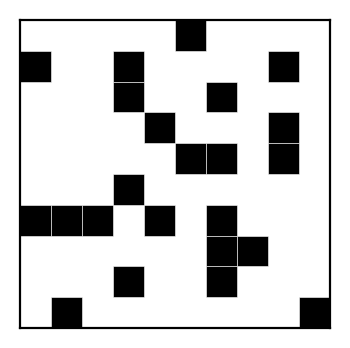

In [198]:
n = 10
p = 0.8

seed = 26_03_02
rng = np.random.default_rng(seed)

test = random_sites(n, p, rng=rng)
display(test)

fig, ax = plt.subplots(figsize=(2, 2), dpi=200)

ax = draw(test, False, ax)

# ax.grid(which="major", axis="both", linestyle="-", color="w", linewidth=1)
ax.set_xticks(np.arange(n+1)-0.5)
ax.set_yticks(np.arange(n+1)-0.5)
ax.tick_params(axis="x", which="major", top=False, labeltop=False, 
                bottom=False, labelbottom=False)
ax.tick_params(axis="y", which="major", left=False, labelleft=False)

plt.show(fig)

In [212]:
def visualize_client(n, p, trials, rng=None):

  figwidth = trials*2
  fig, axes = plt.subplots(nrows=1, ncols=trials, figsize=(figwidth, 2), dpi=200)

  for i in range(trials):
    
    is_open = random_sites(n, p, rng=rng)
    axes[i] = draw(is_open, False, axes[i])

    is_full = flow(is_open)
    axes[i] = draw(is_full, True, axes[i], color="tab:blue")

    # ax.grid(which="major", axis="both", linestyle="-", color="w", linewidth=1)
    axes[i].set_xticks(np.arange(n+1)-0.5)
    axes[i].set_yticks(np.arange(n+1)-0.5)
    axes[i].tick_params(axis="x", which="major", top=False, labeltop=False, 
                        bottom=False, labelbottom=False)
    axes[i].tick_params(axis="y", which="major", left=False, labelleft=False)


  plt.show(fig)

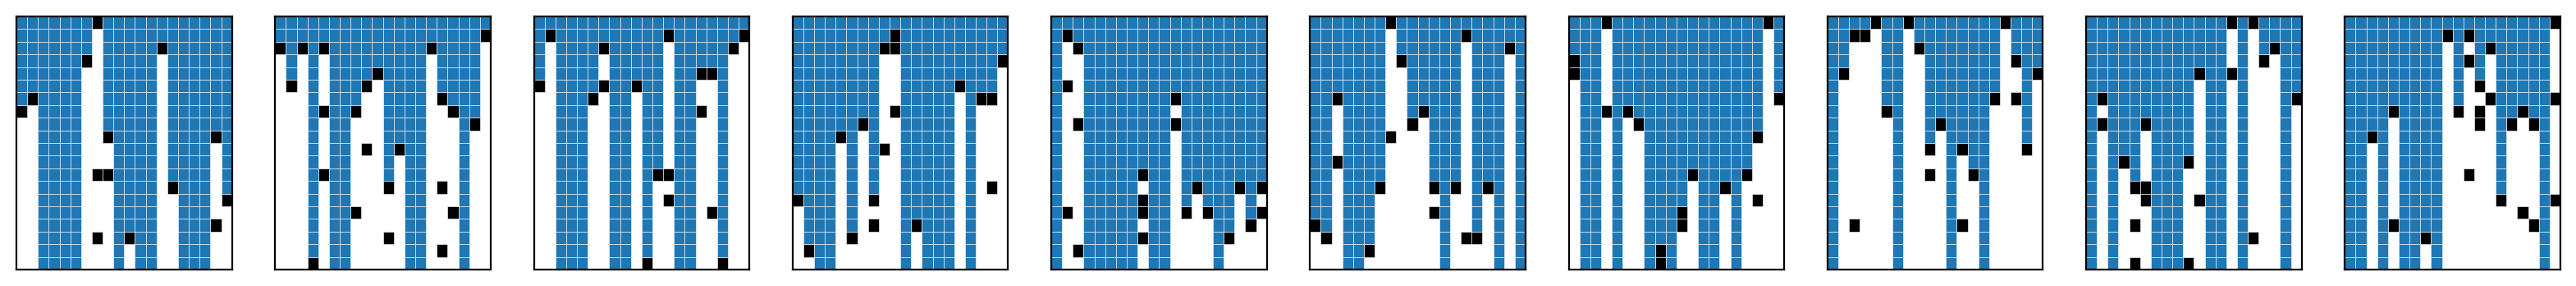

In [ ]:
# seed = 26_03_02
seed = None         # can you find a seed that has no vertical percolation
                    # without changing the p?
rng = np.random.default_rng(seed)

n = 20
p = 0.95
trials = 10       # 10 trials needs > 2 secs

visualize_client(n, p, trials, rng=rng)

**Exploration**
- Modify `flow()` to be able to calculate with different dimension of matrix
  not only square matrix.